In [478]:
import yfinance as yf
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = None

In [479]:
symbol = 'TSLA'
start_date = "2018-01-01"
end_date = "2026-01-31"

tickers = ['TSLA', 'IREN', 'ASTS', 'SNDK','MU','MSFT']

In [480]:
df = yf.download(symbol, start=start_date, end=end_date,multi_level_index=False)

print(df.info())
df.head()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2031 entries, 2018-01-02 to 2026-01-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2031 non-null   float64
 1   High    2031 non-null   float64
 2   Low     2031 non-null   float64
 3   Open    2031 non-null   float64
 4   Volume  2031 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 95.2 KB
None


,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,21.368668,21.474001,20.733334,20.799999,65283000
2018-01-03,21.150000,21.683332,21.036667,21.400000,67822500
2018-01-04,20.974667,21.236668,20.378668,20.858000,149194500
2018-01-05,21.105333,21.149332,20.799999,21.108000,68868000
2018-01-08,22.427334,22.468000,21.033333,21.066668,147891000


In [481]:
print(df.isnull().sum())

df['Daily_Return'] = df['Close'].pct_change() * 100

df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA100'] = df['Close'].rolling(window=100).mean()

df.dropna(inplace=True)

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [482]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
               vertical_spacing=0.03, subplot_titles=(f'{symbol} Stock Price', 'Volume'), 
               row_width=[0.2, 0.7])

fig.add_trace(go.Candlestick(x=df.index, open=df['Open'], high=df['High'],
                low=df['Low'], close=df['Close'], name='Price'), row=1, col=1)

fig.add_trace(go.Scatter(x=df.index, y=df['MA20'], line=dict(color='blue', width=1), name='MA20'), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['MA50'], line=dict(color='red', width=1), name='MA50'), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['MA100'], line=dict(color='green', width=1), name='MA100'), row=1, col=1)

fig.add_trace(go.Bar(x=df.index, y=df['Volume'], name='Volume'), row=2, col=1)

fig.update_layout(title=f'Technical Analysis for {symbol}', xaxis_rangeslider_visible=False, height=800)
fig.show()

In [483]:
fig = px.histogram(df, x="Daily_Return", nbins=50, 
                   title=f'Distribution of {symbol} Daily Returns',
                   marginal="box",
                   color_discrete_sequence=['indianred'])
fig.show()

print(f"Skewness: {df['Daily_Return'].skew()}")
print(f"Kurtosis: {df['Daily_Return'].kurt()}")

Skewness: 0.29207588881214425
Kurtosis: 3.675829403062721


[*********************100%***********************]  6 of 6 completed


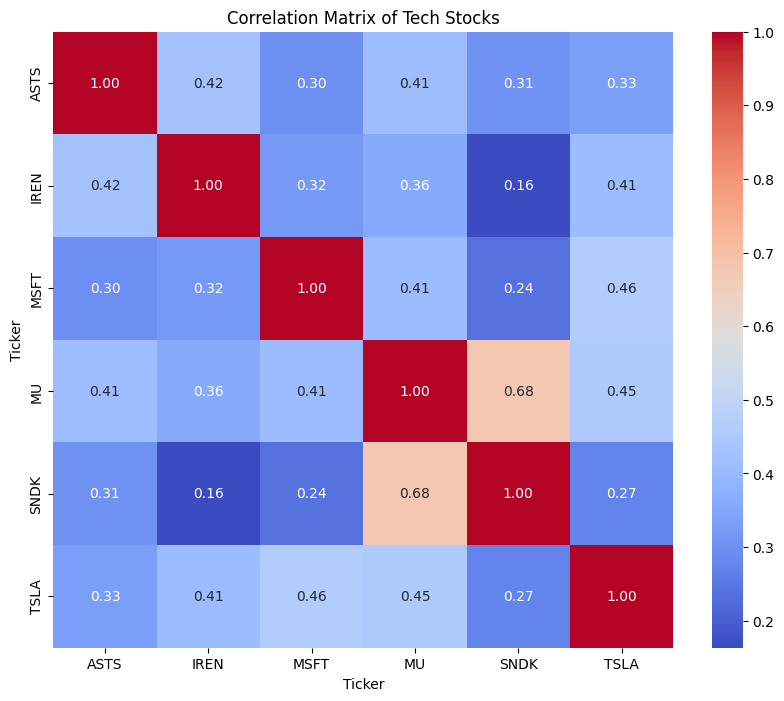

In [484]:
data = yf.download(tickers, start=start_date, end=end_date)['Close']
returns = data.pct_change().dropna()

corr = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Tech Stocks')
plt.show()

In [485]:
df['Cumulative_Return'] = (1 + df['Daily_Return'] / 100).cumprod()

fig = px.line(df, x=df.index, y='Cumulative_Return', 
              title=f'Growth of $1 Investment in {symbol}',
              labels={'Cumulative_Return': 'Portfolio Value'})
fig.show()

In [486]:
rolling_max = df['Close'].cummax()
drawdown = (df['Close'] - rolling_max) / rolling_max

fig = px.area(x=df.index, y=drawdown * 100, 
              title=f'{symbol} Drawdown Analysis (%)',
              labels={'y': 'Drawdown %', 'x': 'Date'})
fig.show()

print(f"Maximum Drawdown: {drawdown.min() * 100:.2f}%")

Maximum Drawdown: -73.63%


In [487]:
df['Volatility_21d'] = df['Daily_Return'].rolling(window=21).std()

fig = px.line(df, x=df.index, y='Volatility_21d', 
              title=f'21-Day Rolling Volatility (Standard Deviation)')
fig.show()

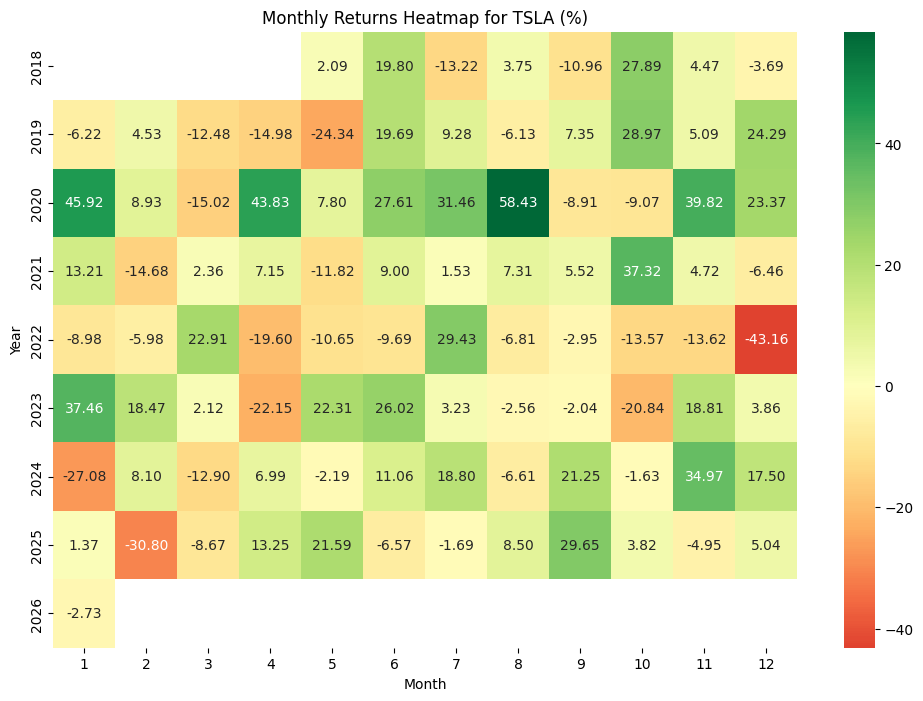

In [488]:
df['Month'] = df.index.month
df['Year'] = df.index.year
monthly_returns = df.groupby(['Year', 'Month'])['Daily_Return'].sum().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(monthly_returns, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title(f'Monthly Returns Heatmap for {symbol} (%)')
plt.show()

In [489]:
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['RSI'], name='RSI'))
fig.add_hline(y=70, line_dash="dash", line_color="red")
fig.add_hline(y=30, line_dash="dash", line_color="green")
fig.update_layout(title=f'{symbol} RSI (14-Day)', yaxis_title='RSI Value')
fig.show()

In [490]:
benchmark_symbol = '^GSPC' # S&P 500
comparison_data = yf.download([symbol, benchmark_symbol], start=start_date, end=end_date)['Close']

normalized_df = (comparison_data / comparison_data.iloc[0]) * 100

fig = px.line(normalized_df, title=f'{symbol} vs S&P 500')
fig.show()

[*********************100%***********************]  2 of 2 completed


In [491]:
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['MACD'], name='MACD', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=df.index, y=df['Signal_Line'], name='Signal Line', line=dict(color='orange')))
fig.add_bar(x=df.index, y=df['MACD'] - df['Signal_Line'], name='Histogram')
fig.update_layout(title=f'MACD for {symbol}', yaxis_title='Value')
fig.show()

In [492]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Data is Stationary (Fit for ML/Stats)")
    else:
        print("Data is Non-Stationary (Must do Differencing)")

print("Testing Raw Close Price:")
check_stationarity(df['Close'])
print("\nTesting Daily Returns:")
check_stationarity(df['Daily_Return'])

Testing Raw Close Price:
ADF Statistic: -1.5245
p-value: 0.5213
Data is Non-Stationary (Must do Differencing)

Testing Daily Returns:
ADF Statistic: -44.7045
p-value: 0.0000
Data is Stationary (Fit for ML/Stats)


In [493]:
df['Z_Score'] = (df['Daily_Return'] - df['Daily_Return'].mean()) / df['Daily_Return'].std()
outliers = df[abs(df['Z_Score']) > 3]

print(f"Found {len(outliers)} outliers in the dataset")
outliers[['Close', 'Daily_Return', 'Z_Score']]

Found 36 outliers in the dataset


,Close,Daily_Return,Z_Score
Date,,,
2018-08-02,23.302668,16.188013,3.940445
2018-09-28,17.651333,-13.901537,-3.496259
2018-10-01,20.713333,17.347133,4.226924
2018-10-23,19.609333,12.718905,3.083046
2019-01-18,20.150667,-12.971116,-3.266303
2019-07-25,15.254667,-13.613708,-3.425121
2019-10-24,19.978666,17.669232,4.306531
2020-02-03,52.000000,19.894859,4.856600
2020-02-04,59.137333,13.725640,3.331863


In [494]:
window = 20
df['MA20'] = df['Close'].rolling(window=window).mean()
df['STD20'] = df['Close'].rolling(window=window).std()

df['Upper_Band'] = df['MA20'] + (df['STD20'] * 2)
df['Lower_Band'] = df['MA20'] - (df['STD20'] * 2)

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['Upper_Band'], name='Upper Band', line=dict(color='rgba(173, 216, 230, 0.5)')))
fig.add_trace(go.Scatter(x=df.index, y=df['Lower_Band'], name='Lower Band', line=dict(color='rgba(173, 216, 230, 0.5)'), fill='tonexty'))
fig.add_trace(go.Scatter(x=df.index, y=df['Close'], name='Close Price', line=dict(color='blue')))
fig.update_layout(title=f'Bollinger Bands for {symbol}', xaxis_rangeslider_visible=False)
fig.show()

In [495]:
import numpy as np

# Assuming Risk-Free Rate of 2% per year
risk_free_rate = 0.02 
daily_rf = (1 + risk_free_rate)**(1/252) - 1

excess_returns = (df['Daily_Return'] / 100) - daily_rf
sharpe_ratio = np.sqrt(252) * excess_returns.mean() / excess_returns.std()

print(f"Sharpe Ratio of {symbol}: {sharpe_ratio:.2f}")
# A value > 1.0 is considered good, > 2.0 is considered very good, > 3.0 is considered outstanding.

Sharpe Ratio of TSLA: 0.93


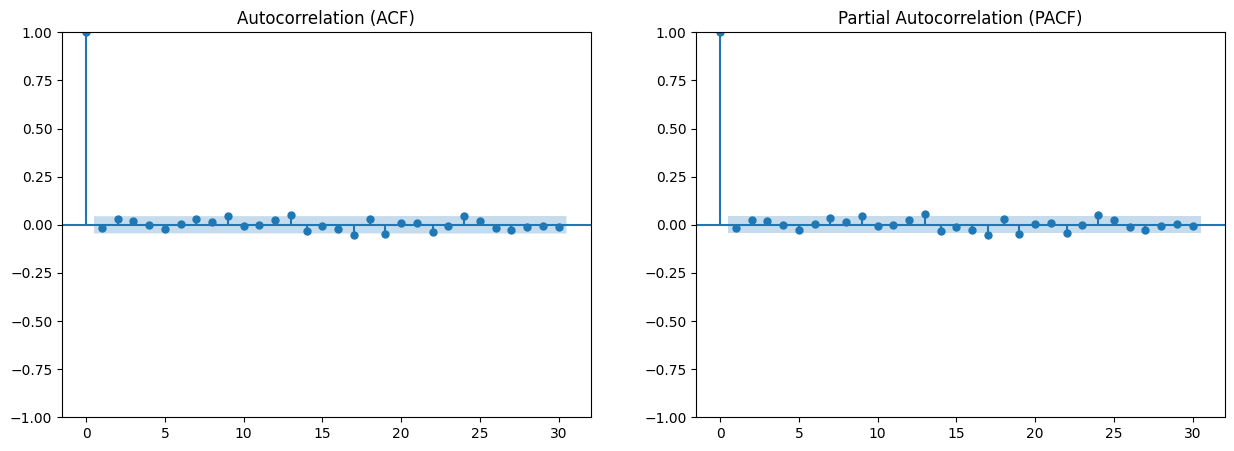

In [496]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ACF: Autocorrelation Function
plot_acf(df['Daily_Return'].dropna(), ax=axes[0], lags=30)
axes[0].set_title('Autocorrelation (ACF)')

# PACF: Partial Autocorrelation Function
plot_pacf(df['Daily_Return'].dropna(), ax=axes[1], lags=30)
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.show()

In [497]:
from scipy import stats

market_returns = comparison_data[benchmark_symbol].pct_change()
stock_returns = comparison_data[symbol].pct_change()

aligned = pd.concat(
    [market_returns, stock_returns],
    axis=1,
    join="inner"
).dropna()

aligned.columns = ["market", "stock"]

beta, alpha, r_value, p_value, std_err = stats.linregress(
    aligned["market"],
    aligned["stock"]
)

print(f"Beta of {symbol}: {beta:.2f}")
print(f"Alpha: {alpha:.6f}")
print(f"R-squared: {r_value**2:.2f}")

Beta of TSLA: 1.63
Alpha: 0.001400
R-squared: 0.25


## Apply Machine Learning

In [498]:
#features for machine learning
features = ['Close', 'Daily_Return', 'MA20', 'MA50', 'RSI', 'MACD', 'Z_Score']
final_df = df[features].dropna()

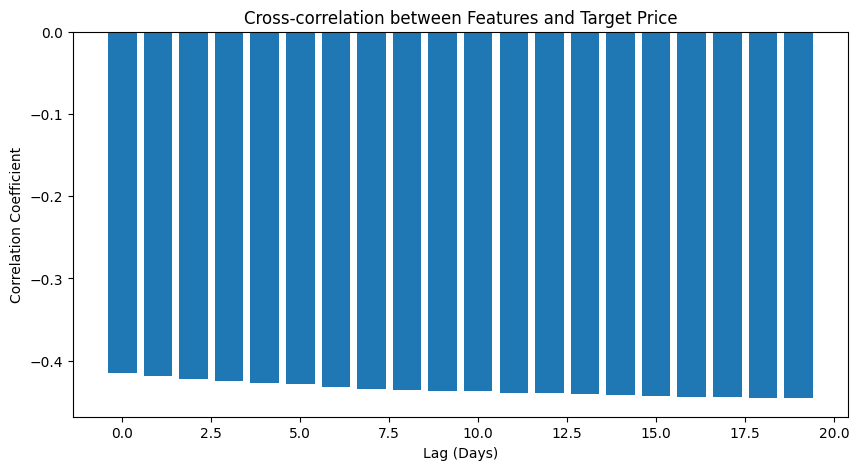

In [499]:
def plot_cross_correlation(x, y, lags=20):
    correlation = [x.corr(y.shift(i)) for i in range(lags)]
    plt.figure(figsize=(10, 5))
    plt.bar(range(lags), correlation)
    plt.title('Cross-correlation between Features and Target Price')
    plt.xlabel('Lag (Days)')
    plt.ylabel('Correlation Coefficient')
    plt.show()

# Example: See how Volume from previous days affects the price today
plot_cross_correlation(df['Volume'], df['Close'])

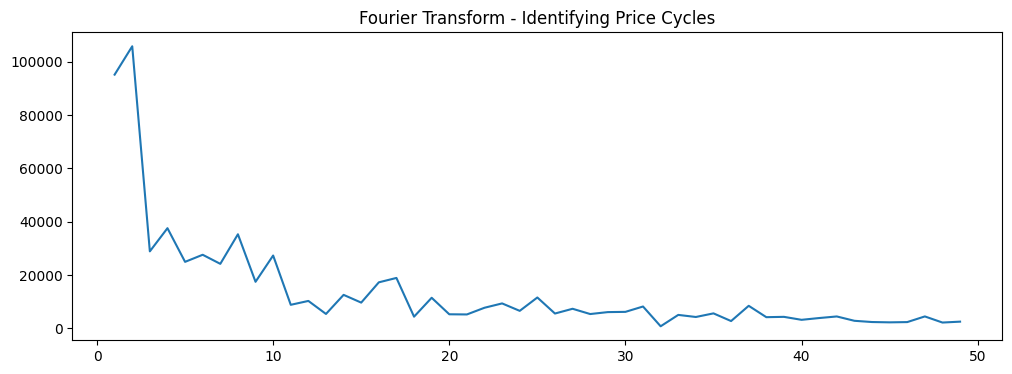

In [500]:
from scipy.fft import fft

close_prices = df['Close'].values
fft_features = fft(close_prices)
fft_df = pd.DataFrame({'fft': fft_features})
fft_df['abs'] = fft_df['fft'].apply(lambda x: np.abs(x))

plt.figure(figsize=(12, 4))
plt.plot(fft_df['abs'].iloc[1:50]) # Remove DC component
plt.title('Fourier Transform - Identifying Price Cycles')
plt.show()

In [501]:
final_df['Target_Next_5D'] = final_df['Close'].shift(-5)

ml_ready_df = final_df.dropna()
print(f"Dataset Size for Training: {ml_ready_df.shape}")

Dataset Size for Training: (1908, 8)


In [502]:
ml_ready_df.head()

,Close,Daily_Return,MA20,MA50,RSI,MACD,Z_Score,Target_Next_5D
Date,,,,,,,,
2018-06-21,23.167334,-4.061070,21.395000,20.208413,69.930564,1.353706,-1.064164,23.328667
2018-06-22,22.242001,-3.994128,21.580933,20.261147,62.406668,1.210090,-1.047619,22.863333
2018-06-25,22.200666,-0.185838,21.761467,20.304707,64.574047,1.080482,-0.106391,22.337999
2018-06-26,22.799999,2.699616,21.955600,20.372427,59.050679,1.014434,0.606756,20.724001
2018-06-27,22.966667,0.731000,22.131533,20.448173,61.512276,0.964422,0.120207,20.610666


In [503]:
print(ml_ready_df.head())

                Close  Daily_Return       MA20       MA50        RSI  \
Date                                                                   
2018-06-21  23.167334     -4.061070  21.395000  20.208413  69.930564   
2018-06-22  22.242001     -3.994128  21.580933  20.261147  62.406668   
2018-06-25  22.200666     -0.185838  21.761467  20.304707  64.574047   
2018-06-26  22.799999      2.699616  21.955600  20.372427  59.050679   
2018-06-27  22.966667      0.731000  22.131533  20.448173  61.512276   

                MACD   Z_Score  Target_Next_5D  
Date                                            
2018-06-21  1.353706 -1.064164       23.328667  
2018-06-22  1.210090 -1.047619       22.863333  
2018-06-25  1.080482 -0.106391       22.337999  
2018-06-26  1.014434  0.606756       20.724001  
2018-06-27  0.964422  0.120207       20.610666  


### LSTM

In [506]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

df = ml_ready_df.copy()
df = df.dropna()

TARGET = "Target_Next_5D"
FEATURES = [col for col in df.columns if col != TARGET]

dates = df.index[WINDOW_SIZE:]
test_dates = dates[split:]

X = df[FEATURES].values
y = df[TARGET].values.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

def create_sequences(X, y, window=20):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

WINDOW_SIZE = 20

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

print("Sample prediction vs true:")
for i in range(5):
    print(f"Pred: {y_pred[i][0]:.2f} | True: {y_true[i][0]:.2f}")


Train shape: (1510, 20, 7)
Test shape: (378, 20, 7)


c:\Users\Patta\AppData\Local\miniconda3\envs\CEDT\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 20, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1437 - mae: 0.2746 - val_loss: 0.0337 - val_mae: 0.1419
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0478 - mae: 0.1677 - val_loss: 0.0294 - val_mae: 0.1349
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0384 - mae: 0.1524 - val_loss: 0.0267 - val_mae: 0.1279
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0351 - mae: 0.1450 - val_loss: 0.0264 - val_mae: 0.1280
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0335 - mae: 0.1417 - val_loss: 0.0253 - val_mae: 0.1242
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0309 - mae: 0.1346 - val_loss: 0.0233 - val_mae: 0.1211
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0307 - mae: 0.1351 - val_loss: 0.0236 - val_mae: 0.1206
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0312 - mae: 0.1363 - val_loss: 0.0231 - val_mae: 0.1207
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.03

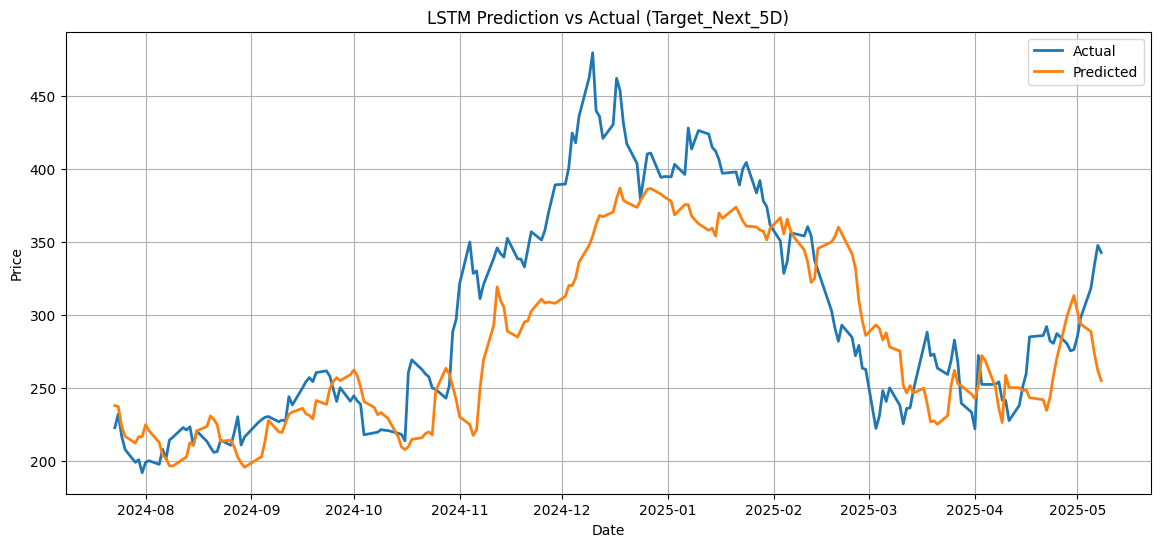

In [507]:
# number of points to plot (avoid overcrowding)
N = 200  

plt.figure(figsize=(14,6))
plt.plot(test_dates[:N], y_true[:N], label="Actual", linewidth=2)
plt.plot(test_dates[:N], y_pred[:N], label="Predicted", linewidth=2)

plt.title("LSTM Prediction vs Actual (Target_Next_5D)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

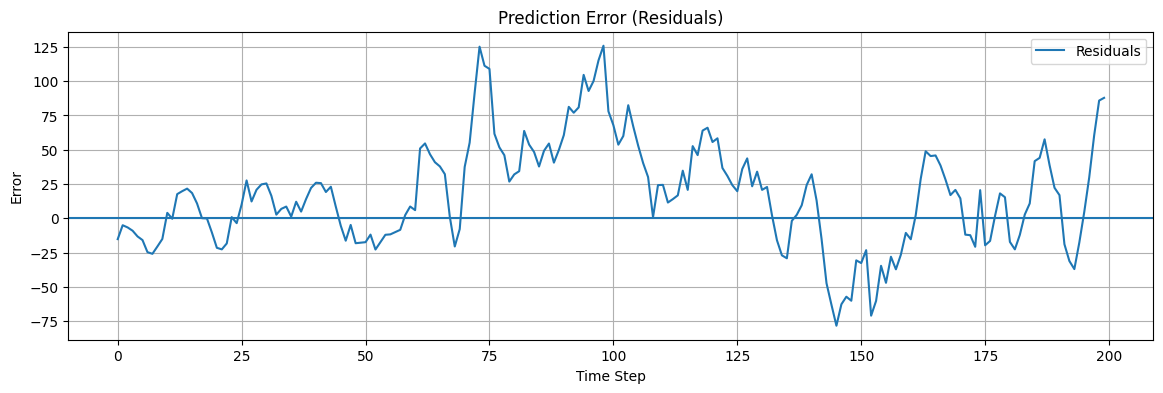

In [508]:
residuals = y_true[:N] - y_pred[:N]

plt.figure(figsize=(14,4))
plt.plot(residuals, label="Residuals")
plt.axhline(0)
plt.title("Prediction Error (Residuals)")
plt.xlabel("Time Step")
plt.ylabel("Error")
plt.legend()
plt.grid(True)

plt.show()

### XGBoost Regression

RMSE: 66.5483
MAE:  52.9729


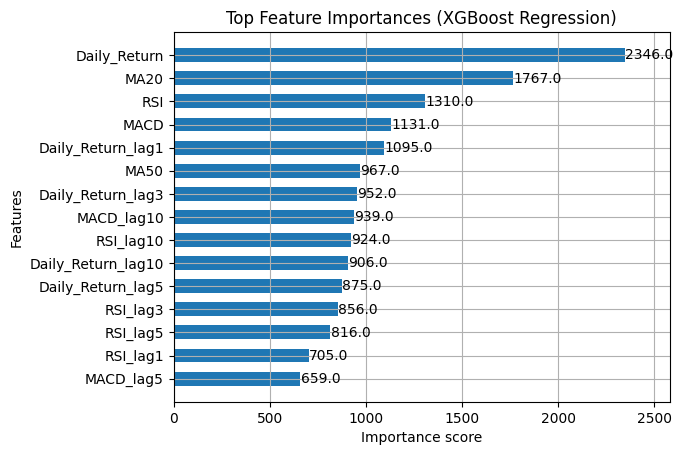

In [509]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

df = ml_ready_df.drop(columns=["Close"]).copy()

TARGET = "Target_Next_5D"
BASE_FEATURES = [c for c in df.columns if c != TARGET]

LAGS = [1, 3, 5, 10]

for lag in LAGS:
    for col in BASE_FEATURES:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

df = df.dropna()

dates = df.index[WINDOW_SIZE:]
test_dates = dates[split:]

FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

import matplotlib.pyplot as plt

xgb.plot_importance(
    model,
    max_num_features=15,
    height=0.6
)

plt.title("Top Feature Importances (XGBoost Regression)")
plt.show()

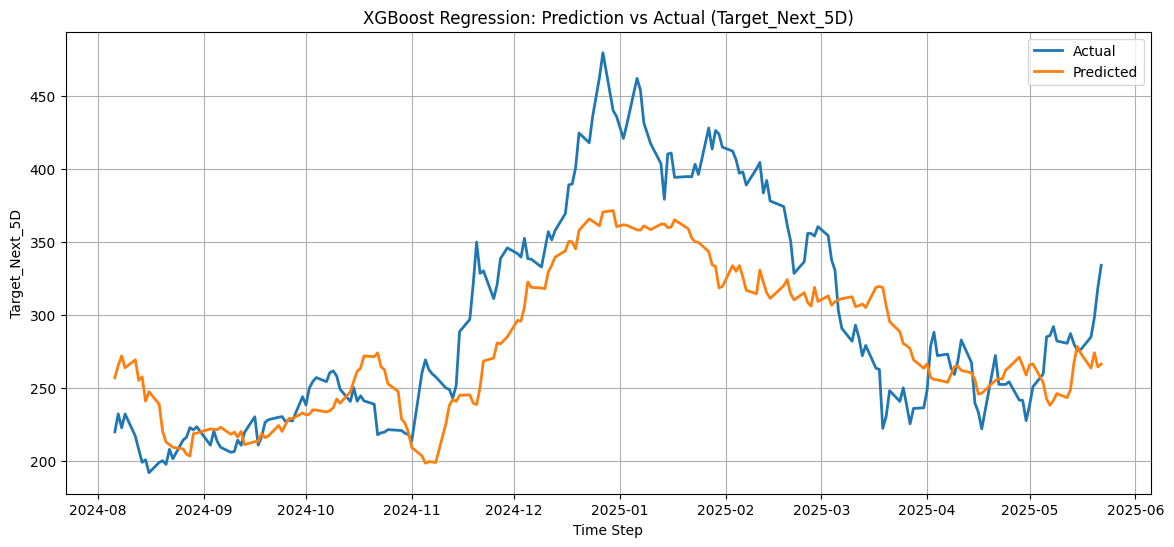

In [510]:
import matplotlib.pyplot as plt

N = 200

plt.figure(figsize=(14,6))
plt.plot(test_dates[:N], y_test.values[:N], label="Actual", linewidth=2)
plt.plot(test_dates[:N], y_pred[:N], label="Predicted", linewidth=2)

plt.title("XGBoost Regression: Prediction vs Actual (Target_Next_5D)")
plt.xlabel("Time Step")
plt.ylabel("Target_Next_5D")
plt.legend()
plt.grid(True)
plt.show()


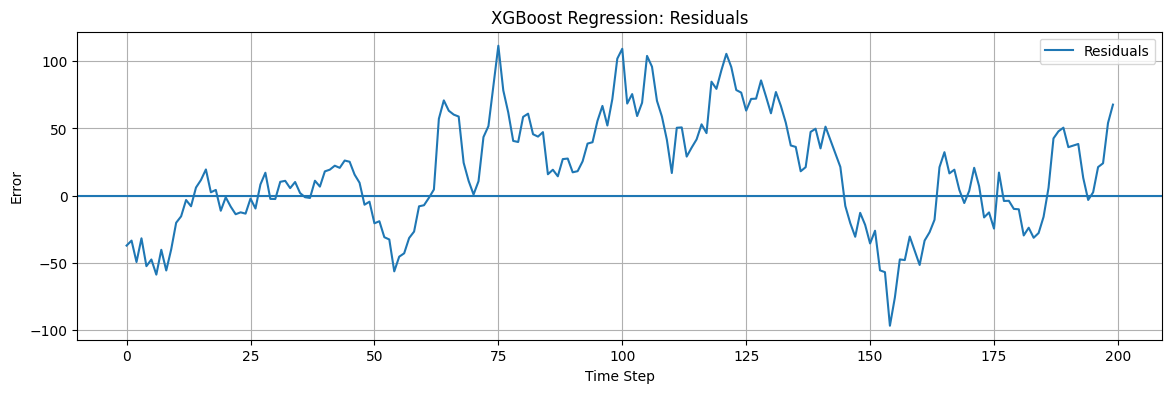

In [511]:
residuals = y_test.values - y_pred

plt.figure(figsize=(14,4))
plt.plot(residuals[:N], label="Residuals")
plt.axhline(0)

plt.title("XGBoost Regression: Residuals")
plt.xlabel("Time Step")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

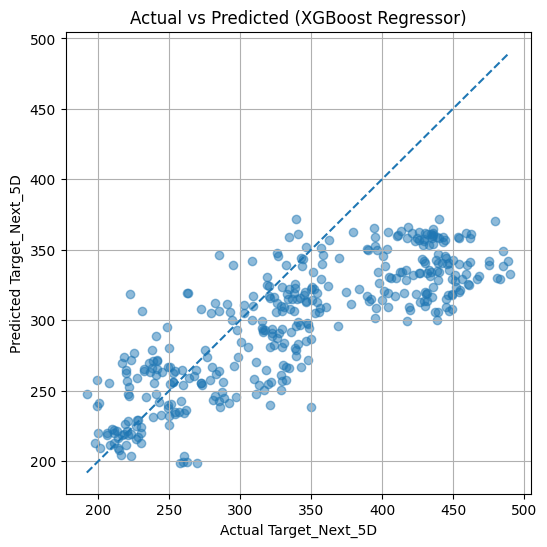

In [512]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.xlabel("Actual Target_Next_5D")
plt.ylabel("Predicted Target_Next_5D")
plt.title("Actual vs Predicted (XGBoost Regressor)")
plt.grid(True)
plt.show()


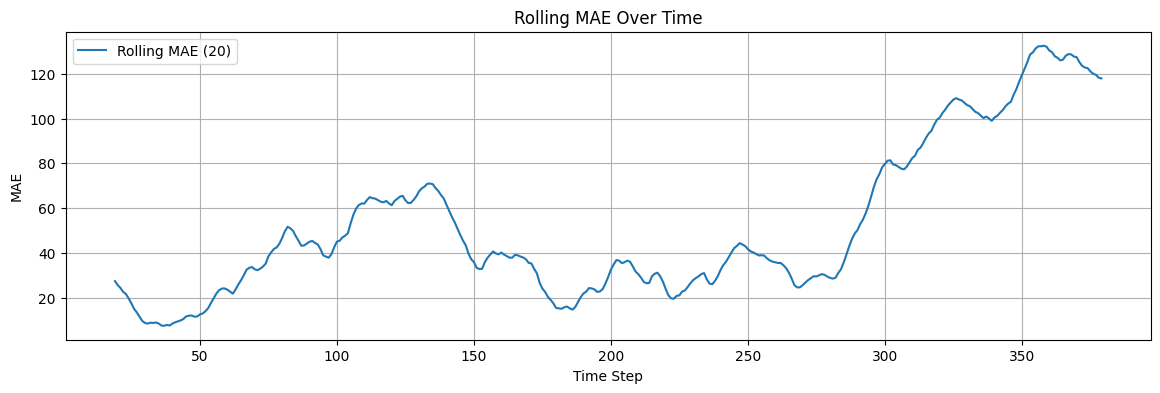

In [513]:
window = 20

errors = np.abs(y_test.values - y_pred)
rolling_mae = pd.Series(errors).rolling(window).mean()

plt.figure(figsize=(14,4))
plt.plot(rolling_mae, label=f"Rolling MAE ({window})")
plt.title("Rolling MAE Over Time")
plt.xlabel("Time Step")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

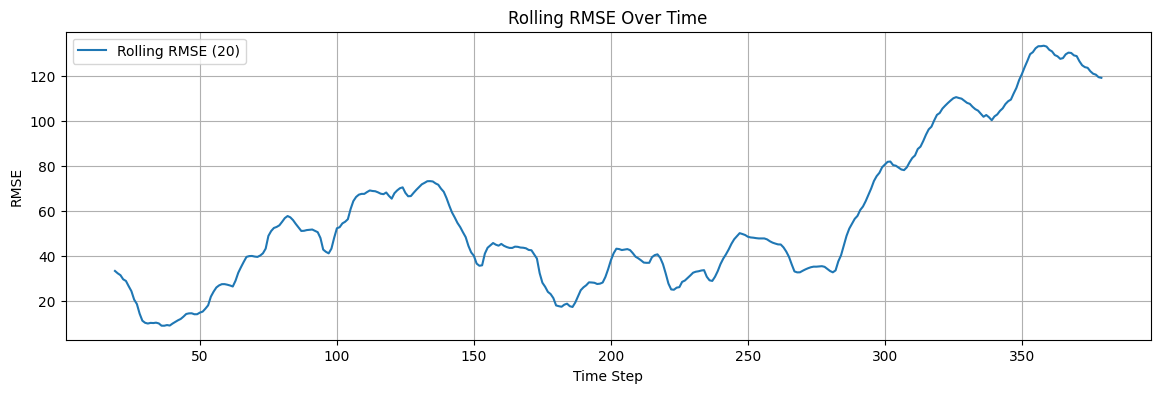

In [514]:
rolling_rmse = (
    pd.Series(errors**2)
    .rolling(window)
    .mean()
    .apply(np.sqrt)
)

plt.figure(figsize=(14,4))
plt.plot(rolling_rmse, label=f"Rolling RMSE ({window})")
plt.title("Rolling RMSE Over Time")
plt.xlabel("Time Step")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

### XGBoost Classification

Accuracy: 0.4737

              precision    recall  f1-score   support

           0       0.48      0.69      0.56       188
           1       0.46      0.27      0.34       192

    accuracy                           0.47       380
   macro avg       0.47      0.48      0.45       380
weighted avg       0.47      0.47      0.45       380

Confusion Matrix:
[[129  59]
 [141  51]]


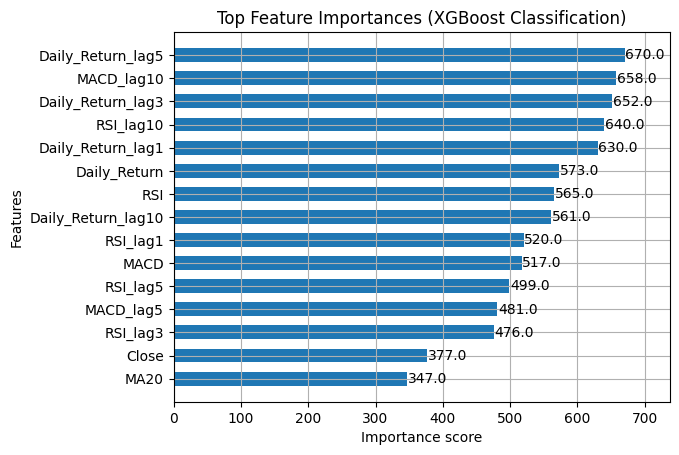

In [515]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

df = ml_ready_df.copy()

df["Target_Class"] = (df["Target_Next_5D"] > df["Close"]).astype(int)

df = df.drop(columns=["Target_Next_5D"])

BASE_FEATURES = [c for c in df.columns if c != "Target_Class"]

LAGS = [1, 3, 5, 10]

for lag in LAGS:
    for col in BASE_FEATURES:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

df = df.dropna()

dates = df.index[WINDOW_SIZE:]
test_dates = dates[split:]

FEATURES = [c for c in df.columns if c != "Target_Class"]

X = df[FEATURES]
y = df["Target_Class"]

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

xgb.plot_importance(
    model,
    max_num_features=15,
    height=0.6
)

plt.title("Top Feature Importances (XGBoost Classification)")
plt.show()

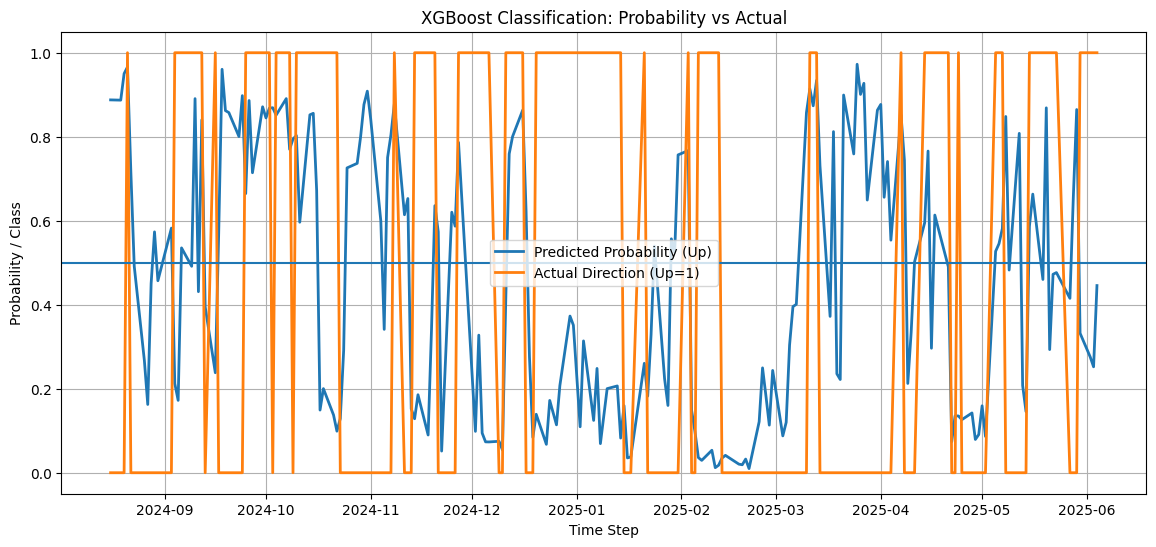

In [516]:
import matplotlib.pyplot as plt
import numpy as np

N = 200

plt.figure(figsize=(14,6))
plt.plot(test_dates[:N],y_prob[:N], label="Predicted Probability (Up)", linewidth=2)
plt.plot(test_dates[:N],y_test.values[:N], label="Actual Direction (Up=1)", linewidth=2)

plt.axhline(0.5)
plt.title("XGBoost Classification: Probability vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Probability / Class")
plt.legend()
plt.grid(True)

plt.show()


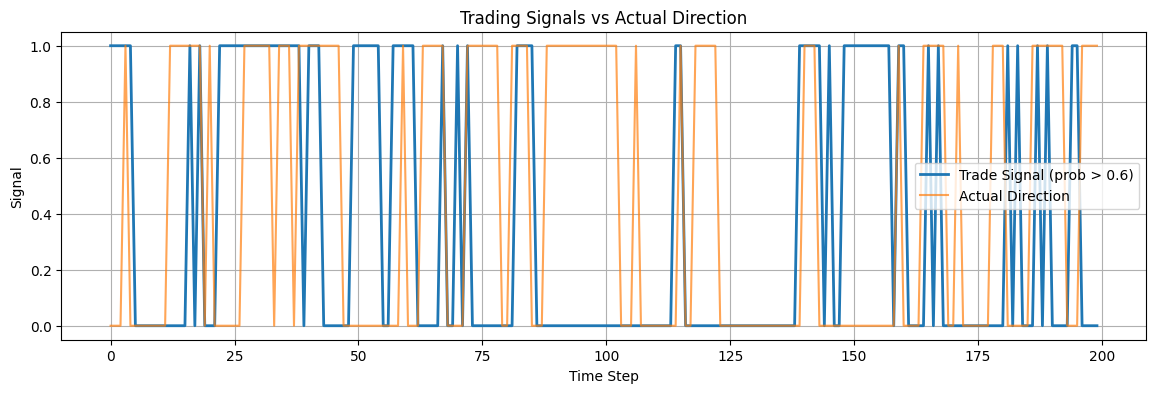

In [517]:
threshold = 0.6
signals = (y_prob > threshold).astype(int)

plt.figure(figsize=(14,4))
plt.plot(signals[:N], label=f"Trade Signal (prob > {threshold})", linewidth=2)
plt.plot(y_test.values[:N], label="Actual Direction", alpha=0.7)

plt.title("Trading Signals vs Actual Direction")
plt.xlabel("Time Step")
plt.ylabel("Signal")
plt.legend()
plt.grid(True)

plt.show()

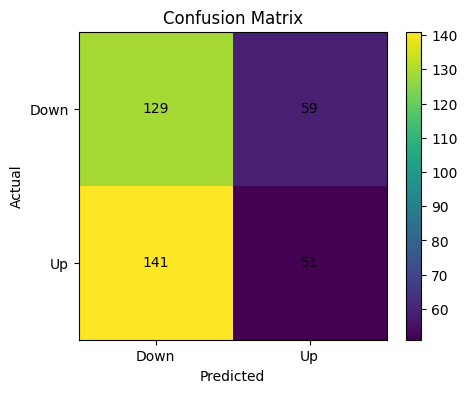

In [518]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Down", "Up"])
plt.yticks([0,1], ["Down", "Up"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()